In [1]:
from torch.utils.data import DataLoader
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR
import scipy.sparse as sp
import pandas as pd
import numpy as np
import random
import os
import math
import argparse
from torch.utils.data import Dataset
from sklearn.preprocessing import StandardScaler
import scipy.sparse as sp
from sklearn.metrics import roc_auc_score,average_precision_score


### 参数设置

In [2]:
parser = argparse.ArgumentParser()
parser.add_argument('--lr', type=float, default=3e-3, help='Initial learning rate.')
parser.add_argument('--epochs', type=int, default= 20, help='Number of epoch.')
parser.add_argument('--num_head', type=list, default=[1,1], help='Number of head attentions.')
parser.add_argument('--alpha', type=float, default=0.2, help='Alpha for the leaky_relu.')
parser.add_argument('--hidden_dim', type=int, default=[256,64], help='The dimension of hidden layer')
parser.add_argument('--output_dim', type=int, default=32, help='The dimension of latent layer')
parser.add_argument('--batch_size', type=int, default=512, help='The size of each batch')
parser.add_argument('--loop', type=bool, default=False, help='whether to add self-loop in adjacent matrix')
parser.add_argument('--seed', type=int, default=8, help='Random seed')#8
parser.add_argument('--Type',type=str,default='KAN', help='score metric')
parser.add_argument('--flag', type=bool, default=False, help='the identifier whether to conduct causal inference')
parser.add_argument('--reduction',type=str,default='concate', help='how to integrate multihead attention')#concate
parser.add_argument('--net', type=str, default='Specific', help='network type')
parser.add_argument('--num', type=int, default=500, help='network scale')
parser.add_argument('--data', type=str, default='lung', help='data type')

args = parser.parse_args([])


In [3]:
seed = args.seed
random.seed(args.seed)
torch.manual_seed(args.seed)
np.random.seed(args.seed)
data_type = args.data
net_type = args.net
datasetpath = 'GeneKAN/Dataset/Benchmark Dataset/'

### 文件读取

In [4]:
class scRNADataset(Dataset):
    def __init__(self,train_set,num_gene,flag=False):
        super(scRNADataset, self).__init__()
        self.train_set = train_set
        self.num_gene = num_gene
        self.flag = flag


    def __getitem__(self, idx):
        train_data = self.train_set[:,:2]
        train_label = self.train_set[:,-1]

        if self.flag:
            train_len = len(train_label)
            train_tan = np.zeros([train_len,2])
            train_tan[:,0] = 1 - train_label
            train_tan[:,1] = train_label
            train_label = train_tan

        data = train_data[idx].astype(np.int64)
        label = train_label[idx].astype(np.float32)

        return data, label

    def __len__(self):
        return len(self.train_set)


    def Adj_Generate(self,TF_set,direction=False, loop=False):

        adj = sp.dok_matrix((self.num_gene, self.num_gene), dtype=np.float32)



        for pos in self.train_set:

            tf = pos[0]
            target = pos[1]

            if direction == False:
                if pos[-1] == 1:
                    # p=np.random.uniform(0, 1)
                    # if p>pval:
                    adj[tf, target] = 1.0
                    adj[target, tf] = 1.0
            else:
                if pos[-1] == 1:
                    adj[tf, target] = 1.0
                    if target in TF_set:
                        adj[target, tf] = 1.0


        if loop:
            adj = adj + sp.identity(self.num_gene)

        adj = adj.todok()


        return adj



class load_data():
    def __init__(self, data, normalize=True):
        self.data = data
        self.normalize = normalize

    def data_normalize(self,data):
        standard = StandardScaler()
        epr = standard.fit_transform(data.T)

        return epr.T


    def exp_data(self):
        data_feature = self.data.values

        if self.normalize:
            data_feature = self.data_normalize(data_feature)

        data_feature = data_feature.astype(np.float32)

        return data_feature


def adj2saprse_tensor(adj):
    coo = adj.tocoo()
    i = torch.LongTensor([coo.row, coo.col])
    v = torch.from_numpy(coo.data).float()

    adj_sp_tensor = torch.sparse_coo_tensor(i, v, coo.shape)
    return adj_sp_tensor

In [5]:
def embed2file(tf_embed,tg_embed,gene_file,tf_file,target_path):
    tf_embed = tf_embed.cpu().detach().numpy()
    tg_embed = tg_embed.cpu().detach().numpy()

    gene_set = pd.read_csv(gene_file, index_col=0)

    tf_embed = pd.DataFrame(tf_embed,index=gene_set['Gene'].values)
    tg_embed = pd.DataFrame(tg_embed, index=gene_set['Gene'].values)

    tf_embed.to_csv(tf_file)
    tg_embed.to_csv(target_path)

exp_file = datasetpath + net_type + ' Dataset/' + data_type + '/TFs+' + str(args.num) + '/BL--ExpressionData.csv'
tf_file = datasetpath + net_type + ' Dataset/' + data_type + '/TFs+' + str(args.num) + '/TF.csv'
target_file = datasetpath + net_type + ' Dataset/' + data_type + '/TFs+' + str(args.num) + '/Target.csv'



In [6]:
train_file =  'GeneKAN' + '/' + net_type + '/' + data_type + ' ' + str(args.num) + '/Train_set.csv'
val_file = 'GeneKAN' + '/' + net_type + '/' + data_type + ' ' + str(args.num) +  '/Validation_set.csv'
test_file = 'GeneKAN' + '/' + net_type + '/' + data_type + ' ' + str(args.num)  + '/Test_set.csv'

tf_embed_path = r'Result/'+net_type+'/'+data_type+' '+str(args.num)+'/Channel1.csv'
target_embed_path = r'Result/'+net_type+'/'+data_type+' '+str(args.num)+'/Channel2.csv'
if not os.path.exists('Result/'+net_type+'/'+data_type+' '+str(args.num)):
    os.makedirs('Result/'+net_type+'/'+data_type+' '+str(args.num))

data_input = pd.read_csv(exp_file,index_col=0)
loader = load_data(data_input)
feature = loader.exp_data()
tf = pd.read_csv(tf_file,index_col=0)['index'].values.astype(np.int64)
target = pd.read_csv(target_file,index_col=0)['index'].values.astype(np.int64)
feature = torch.from_numpy(feature)
tf = torch.from_numpy(tf)

#device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')
data_feature = feature.to(device)
tf = tf.to(device)


train_data = pd.read_csv(train_file, index_col=0).values
validation_data = pd.read_csv(val_file, index_col=0).values
test_data = pd.read_csv(test_file, index_col=0).values

train_load = scRNADataset(train_data, feature.shape[0], flag=args.flag)
adj = train_load.Adj_Generate(tf,loop=args.loop)


adj = adj2saprse_tensor(adj)
train_data = torch.from_numpy(train_data)
test_data = torch.from_numpy(test_data)
val_data = torch.from_numpy(validation_data)
#
gamma_list = [0.5,1]  # 每层的 gamma 值[0.5,1]

C:\Users\Tripletdc\AppData\Local\Temp\ipykernel_30080\2020680543.py:88: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ..\torch\csrc\utils\tensor_new.cpp:264.)
  i = torch.LongTensor([coo.row, coo.col])


### 评估函数

In [7]:
def Evaluation(y_true, y_result_df,flag=False):
    if flag:
        # y_p = torch.argmax(y_result_df,dim=1)
        y_p = y_result_df[:,-1]
        y_p = y_p.cpu().detach().numpy()
        y_p = y_p.flatten()
    else:
        y_p = y_result_df.cpu().detach().numpy()
        y_p = y_p.flatten()


    y_t = y_true.cpu().numpy().flatten().astype(int)

    AUC = roc_auc_score(y_true=y_t, y_score=y_p)


    AUPR = average_precision_score(y_true=y_t,y_score=y_p)
    AUPR_norm = AUPR/np.mean(y_t)


    return AUC, AUPR, AUPR_norm




def normalize(expression):
    std = StandardScaler()
    epr = std.fit_transform(expression)

    return epr


### 模型设计

In [8]:
import matplotlib.pyplot as plt
class KANLinear(torch.nn.Module):
    def __init__(
        self,
        in_features,
        out_features,
        grid_size=5,
        spline_order=3,
        scale_noise=0.1,
        scale_base=1.0,
        scale_spline=1.0,
        enable_standalone_scale_spline=True,
        base_activation=torch.nn.SiLU,
        grid_eps=0.02,
        grid_range=[-1, 1],
    ):
        super(KANLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order

        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = (
            (
                torch.arange(-spline_order, grid_size + spline_order + 1) * h
                + grid_range[0]
            )
            .expand(in_features, -1)
            .contiguous()
        )
        self.register_buffer("grid", grid)

        self.base_weight = torch.nn.Parameter(torch.Tensor(out_features, in_features))
        self.spline_weight = torch.nn.Parameter(
            torch.Tensor(out_features, in_features, grid_size + spline_order)
        )
        if enable_standalone_scale_spline:
            self.spline_scaler = torch.nn.Parameter(
                torch.Tensor(out_features, in_features)
            )

        self.scale_noise = scale_noise
        self.scale_base = scale_base
        self.scale_spline = scale_spline
        self.enable_standalone_scale_spline = enable_standalone_scale_spline
        self.base_activation = base_activation()
        self.grid_eps = grid_eps

        self.reset_parameters()

    def reset_parameters(self):
        torch.nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5) * self.scale_base)
        with torch.no_grad():
            noise = (
                (
                    torch.rand(self.grid_size + 1, self.in_features, self.out_features)
                    - 1 / 2
                )
                * self.scale_noise
                / self.grid_size
            )
            self.spline_weight.data.copy_(
                (self.scale_spline if not self.enable_standalone_scale_spline else 1.0)
                * self.curve2coeff(
                    self.grid.T[self.spline_order : -self.spline_order],
                    noise,
                )
            )
            if self.enable_standalone_scale_spline:
                torch.nn.init.kaiming_uniform_(self.spline_scaler, a=math.sqrt(5) * self.scale_spline)

    def b_splines(self, x: torch.Tensor):
        assert x.dim() == 2 and x.size(1) == self.in_features

        grid: torch.Tensor = self.grid
        x = x.unsqueeze(-1)
        bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).to(x.dtype)
        for k in range(1, self.spline_order + 1):
            bases = (
                (x - grid[:, : -(k + 1)])
                / (grid[:, k:-1] - grid[:, : -(k + 1)])
                * bases[:, :, :-1]
            ) + (
                (grid[:, k + 1 :] - x)
                / (grid[:, k + 1 :] - grid[:, 1:(-k)])
                * bases[:, :, 1:]
            )

        assert bases.size() == (
            x.size(0),
            self.in_features,
            self.grid_size + self.spline_order,
        )
        return bases.contiguous()

    def curve2coeff(self, x: torch.Tensor, y: torch.Tensor):
        assert x.dim() == 2 and x.size(1) == self.in_features
        assert y.size() == (x.size(0), self.in_features, self.out_features)

        A = self.b_splines(x).transpose(
            0, 1
        )
        B = y.transpose(0, 1)
        solution = torch.linalg.lstsq(
            A, B
        ).solution
        result = solution.permute(
            2, 0, 1
        )

        assert result.size() == (
            self.out_features,
            self.in_features,
            self.grid_size + self.spline_order,
        )
        return result.contiguous()

    @property
    def scaled_spline_weight(self):
        return self.spline_weight * (
            self.spline_scaler.unsqueeze(-1)
            if self.enable_standalone_scale_spline
            else 1.0
        )

    def forward(self, x: torch.Tensor):
        assert x.dim() == 2 and x.size(1) == self.in_features

        base_output = F.linear(self.base_activation(x), self.base_weight)
        spline_output = F.linear(
            self.b_splines(x).view(x.size(0), -1),
            self.scaled_spline_weight.view(self.out_features, -1),
        )
        return base_output + spline_output

    @torch.no_grad()
    def update_grid(self, x: torch.Tensor, margin=0.01):
        assert x.dim() == 2 and x.size(1) == self.in_features
        batch = x.size(0)

        splines = self.b_splines(x)
        splines = splines.permute(1, 0, 2)
        orig_coeff = self.scaled_spline_weight
        orig_coeff = orig_coeff.permute(1, 2, 0)
        unreduced_spline_output = torch.bmm(splines, orig_coeff)
        unreduced_spline_output = unreduced_spline_output.permute(
            1, 0, 2
        )

        x_sorted = torch.sort(x, dim=0)[0]
        grid_adaptive = x_sorted[
            torch.linspace(
                0, batch - 1, self.grid_size + 1, dtype=torch.int64, device=x.device
            )
        ]

        uniform_step = (x_sorted[-1] - x_sorted[0] + 2 * margin) / self.grid_size
        grid_uniform = (
            torch.arange(
                self.grid_size + 1, dtype=torch.float32, device=x.device
            ).unsqueeze(1)
            * uniform_step
            + x_sorted[0]
            - margin
        )

        grid = self.grid_eps * grid_uniform + (1 - self.grid_eps) * grid_adaptive
        grid = torch.concatenate(
            [
                grid[:1]
                - uniform_step
                * torch.arange(self.spline_order, 0, -1, device=x.device).unsqueeze(1),
                grid,
                grid[-1:]
                + uniform_step
                * torch.arange(1, self.spline_order + 1, device=x.device).unsqueeze(1),
            ],
            dim=0,
        )

        self.grid.copy_(grid.T)
        self.spline_weight.data.copy_(self.curve2coeff(x, unreduced_spline_output))

    def regularization_loss(self, regularize_activation=1.0, regularize_entropy=1.0):
        l1_fake = self.spline_weight.abs().mean(-1)
        regularization_loss_activation = l1_fake.sum()
        p = l1_fake / regularization_loss_activation
        regularization_loss_entropy = -torch.sum(p * p.log())
        return (
            regularize_activation * regularization_loss_activation
            + regularize_entropy * regularization_loss_entropy
        )


def plot_activation_function(kan_linear, input_range):
    x = torch.linspace(input_range[0], input_range[1], 100).unsqueeze(1)

    # Repeat the input tensor to create a batch
    x = x.expand(-1, kan_linear.in_features).contiguous()

    with torch.no_grad():
        y = kan_linear(x).numpy()

    plt.figure(figsize=(10, 6))
    plt.plot(x.numpy(), y, label='KAN Activation')
    plt.xlabel('Input')
    plt.ylabel('Output')
    plt.title('KAN Learnable Activation Function')
    plt.legend()
    plt.grid(True)
    plt.show()





In [9]:
class GCKLayer(nn.Module):
    def __init__(self, gamma, layer):
        super(GCKLayer, self).__init__()
        self.gamma = gamma
        self.layer = layer

    def rbf_kernel_X(self, X, gamma):
        n = X.shape[0]
        Sij = torch.matmul(X, X.T)
        Si = torch.unsqueeze(torch.diag(Sij), 0).T @ torch.ones(1, n).to(X.device)
        Sj = torch.ones(n, 1).to(X.device) @ torch.unsqueeze(torch.diag(Sij), 0)
        D2 = Si + Sj - 2 * Sij
        return torch.exp(-D2 * gamma)

    def rbf_kernel_K(self, K_t, gamma):
        n = K_t.shape[0]
        s = torch.unsqueeze(torch.diag(K_t), 0)
        D2 = torch.ones(n, 1).to(K_t.device) @ s + s.T @ torch.ones(1, n).to(K_t.device) - 2 * K_t
        return torch.exp(-D2 * gamma)

    def forward(self, adj, inputs):
        if self.layer == 0:
            X_t = torch.matmul(adj, inputs)
            return self.rbf_kernel_X(X_t, self.gamma)
        else:
            K_t = torch.matmul(torch.matmul(adj, inputs), adj.t())
            return self.rbf_kernel_K(K_t, self.gamma)

class GCKM(nn.Module):
    def __init__(self, gamma_list):
        super(GCKM, self).__init__()
        self.model = nn.ModuleList()
        for i, gamma in enumerate(gamma_list):
            self.model.append(GCKLayer(gamma, i))

    def forward(self, adj, X):
        K = X
        for layer in self.model:
            K = layer(adj, K)
        return K

class GCKMGRN(nn.Module):
    def __init__(self, input_dim, hidden1_dim, hidden2_dim, output_dim, gamma_list,
                 alpha, device, reduction, num_nodes, num_head1, num_head2,
                 decode_type='KAN'):
        super(GCKMGRN, self).__init__()
        self.device = device
        self.alpha = alpha
        self.reduction = reduction
        self.num_nodes = num_nodes
        self.gamma = gamma_list
        self.num_head1 = num_head1
        self.num_head2 = num_head2
        self.decode_type = decode_type

        # 初始化多头GCKM层
        self.gckm1 = nn.ModuleList([GCKM(gamma_list) for _ in range(num_head1)])
        self.gckm2 = nn.ModuleList([GCKM(gamma_list) for _ in range(num_head2)])
        
        # 注意力权重参数
        self.attn_weights1 = nn.Parameter(torch.Tensor(num_head1))
        self.attn_weights2 = nn.Parameter(torch.Tensor(num_head2))
        nn.init.normal_(self.attn_weights1)
        nn.init.normal_(self.attn_weights2)

        # 维度处理
        self.hidden1_dim = hidden1_dim * num_head1 if reduction == 'concate' else hidden1_dim
        self.hidden2_dim = hidden2_dim * num_head2 if reduction == 'concate' else hidden2_dim
        
        # 投影层
        self.linear_0 = nn.Linear(num_nodes * num_head2, self.hidden2_dim)
        self.tf_linear1 = nn.Linear(self.hidden2_dim, output_dim)
        self.target_linear1 = nn.Linear(self.hidden2_dim, output_dim)

        # 解码器配置
        if decode_type == 'MLP':
            self.linear = nn.Linear(2 * output_dim, 1)
        elif decode_type == 'KAN':
            self.linear = KANLinear(2 * output_dim, 1)
        
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.tf_linear1.weight)
        nn.init.xavier_uniform_(self.target_linear1.weight)
        if self.decode_type == 'MLP':
            nn.init.xavier_uniform_(self.linear.weight)
            nn.init.zeros_(self.linear.bias)

    def encode(self, x, adj):
        # 第一层多头注意力融合
        gckm1_outputs = [gckm(adj, x) for gckm in self.gckm1]
        stacked_gckm1 = torch.stack(gckm1_outputs, dim=0)  # [h1, n, n]
        attn1 = F.softmax(self.attn_weights1, dim=0)
        K1 = torch.einsum('h,hij->ij', attn1, stacked_gckm1)
        K1 = F.elu(K1)

        # 第二层多头注意力融合
        gckm2_outputs = [gckm(adj, K1) for gckm in self.gckm2]
        stacked_gckm2 = torch.stack(gckm2_outputs, dim=0)  # [h2, n, n]
        attn2 = F.softmax(self.attn_weights2, dim=0)
        K2 = torch.einsum('h,hij->ij', attn2, stacked_gckm2)
        K2 = F.elu(K2)

        # 降维处理
        if self.reduction == 'mean':
            embed = torch.mean(K2, dim=1)
        elif self.reduction == 'concate':
            embed = K2.view(K2.size(0), -1)
        return embed

    def decode(self, tf_embed, target_embed):
        if self.decode_type == 'dot':
            return torch.sum(tf_embed * target_embed, dim=1, keepdim=True)
        elif self.decode_type == 'cosine':
            return F.cosine_similarity(tf_embed, target_embed, dim=1).unsqueeze(1)
        else:
            combined = torch.cat([tf_embed, target_embed], dim=1)
            return self.linear(combined)

    def forward(self, x, adj, train_sample):
        embed = self.encode(x, adj)
        embed = F.dropout(F.elu(self.linear_0(embed)), p=0.01)
        
        tf_embed = F.elu(self.tf_linear1(embed))
        target_embed = F.elu(self.target_linear1(embed))
        
        train_tf = tf_embed[train_sample[:, 0]]
        train_target = target_embed[train_sample[:, 1]]
        return self.decode(train_tf, train_target)

    def get_embedding(self):
        return self.tf_linear1.weight, self.target_linear1.weight

class Transformer(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_heads, num_layers, output_dim):
        super(Transformer, self).__init__()
        self.encoder_layer = nn.TransformerEncoderLayer(d_model=input_dim, nhead=num_heads)
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.fc(self.transformer_encoder(x))

### 模型训练

In [10]:
class EarlyStopping:
    """Early stops the training if validation loss doesn't improve after a given patience."""
    def __init__(self,save_dir, patience=7,verbose=False, delta=0):
        """
        Args:
            patience (int): How long to wait after last time validation loss improved.
                           
                            Default: 7
            verbose (bool): If True, prints a message for each validation loss improvement.
                            
                            Default: False
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
                           
                            Default: 0
        """
        self.patience = patience
        self.verbose = verbose
        self.save_dir = save_dir
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta

    def __call__(self, val_loss, model):

        score = val_loss

        if self.best_score is None:
            self.best_score = score
            #self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            #self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''
        Saves model when validation loss decrease.
       
        '''
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        # torch.save(model.state_dict(), 'checkpoint.pt')     
        torch.save(model.state_dict(), self.save_dir+'.pkl')                 
        self.val_loss_min = val_loss



In [11]:
model = GCKMGRN(input_dim=feature.size()[1],
                hidden1_dim=args.hidden_dim[0],
                hidden2_dim=args.hidden_dim[1],
                output_dim=args.output_dim,
                gamma_list=gamma_list,
                alpha=args.alpha,
                device=device,
                reduction=args.reduction,
                num_nodes=feature.shape[0],
                num_head1=args.num_head[0],
                num_head2=args.num_head[1]
                )


adj = adj.to(device)
model = model.to(device)
train_data = train_data.to(device)
test_data = test_data.to(device)
validation_data = val_data.to(device)


optimizer = Adam(model.parameters(), lr=args.lr)
scheduler = StepLR(optimizer, step_size=1, gamma=0.99)
early_stopping = EarlyStopping(save_dir='./',patience=5, verbose=True)
model_path = '../model'
if not os.path.exists(model_path):
    os.makedirs(model_path)



for epoch in range(args.epochs):
    running_loss = 0.0

    for train_x, train_y in DataLoader(train_load, batch_size=args.batch_size, shuffle=True):
        model.train()
        optimizer.zero_grad()

        if args.flag:
            train_y = train_y.to(device)
        else:
            train_y = train_y.to(device).view(-1, 1)


        # train_y = train_y.to(device).view(-1, 1)
        result_df = model(data_feature, adj, train_x)

        #result_df = torch.sigmoid(result_df)
        if args.flag:
            result_df = torch.softmax(result_df, dim=1)
        else:

            result_df = torch.sigmoid(result_df)

        loss_BCE = F.binary_cross_entropy(result_df, train_y)



        loss_BCE.backward()
        optimizer.step()
        scheduler.step()

        running_loss += loss_BCE.item()


    model.eval()

    score = model(data_feature, adj, validation_data)
    if args.flag:
        score = torch.softmax(score, dim=1)
    else:
        score = torch.sigmoid(score)


    # score = torch.sigmoid(score)

    AUC, AUPR, AUPR_norm = Evaluation(y_result_df=score, y_true=validation_data[:, -1],flag=args.flag)
    early_stopping(AUC, model)

    print('Epoch:{}'.format(epoch + 1),
            'train loss:{}'.format(running_loss),
            'AUC:{:.3F}'.format(AUC),
            'AUPR:{:.3F}'.format(AUPR))
    if early_stopping.early_stop:
        print("Early stopping")
        break





Epoch:1 train loss:8.598059803247452 AUC:0.763 AUPR:0.646
Epoch:2 train loss:7.52356418967247 AUC:0.789 AUPR:0.745
Epoch:3 train loss:6.796044796705246 AUC:0.800 AUPR:0.763
Epoch:4 train loss:6.447701394557953 AUC:0.804 AUPR:0.766
Epoch:5 train loss:6.269790947437286 AUC:0.806 AUPR:0.770
Epoch:6 train loss:6.158704161643982 AUC:0.811 AUPR:0.774
Epoch:7 train loss:6.078824430704117 AUC:0.815 AUPR:0.776
Epoch:8 train loss:6.065154403448105 AUC:0.816 AUPR:0.778
EarlyStopping counter: 1 out of 5
Epoch:9 train loss:5.9575735330581665 AUC:0.811 AUPR:0.776
EarlyStopping counter: 2 out of 5
Epoch:10 train loss:5.912124842405319 AUC:0.813 AUPR:0.777
EarlyStopping counter: 3 out of 5
Epoch:11 train loss:5.859103739261627 AUC:0.814 AUPR:0.779
EarlyStopping counter: 4 out of 5
Epoch:12 train loss:5.8346318900585175 AUC:0.813 AUPR:0.778
EarlyStopping counter: 5 out of 5
Epoch:13 train loss:5.829890608787537 AUC:0.812 AUPR:0.778
Early stopping


### 模型测试（fig3-fig6）基于模型性能数值画ppt柱状图

In [12]:
model.eval()


score = model(data_feature, adj, test_data)
if args.flag:
    score = torch.softmax(score, dim=1)
else:

    score = torch.sigmoid(score)


AUC, AUPR, AUPR_norm = Evaluation(y_result_df=score, y_true=test_data[:, -1],flag=args.flag)

print('AUC:{}'.format(AUC),
     'AUPRC:{}'.format(AUPR))

AUC:0.8155618060894154 AUPRC:0.7764693212235563


In [13]:
import traceback

try:
    score_np = score.detach().cpu().numpy()
    # 处理可能的多维输出
    if score_np.ndim > 1:
        if score_np.shape[1] > 1:
            scores = score_np[:, 1]
        else:
            scores = score_np.reshape(-1)
    else:
        scores = score_np.reshape(-1)

    test_np = test_data.detach().cpu().numpy()
    if test_np.ndim == 1:
        test_np = test_np.reshape(-1, 1)
    cols = test_np.shape[1]

    if cols >= 2:
        tf_idx = test_np[:, 0].astype(int)
        gene_idx = test_np[:, 1].astype(int)
    else:
        tf_idx = np.arange(len(scores))
        gene_idx = np.arange(len(scores))

    labels = test_np[:, -1] if cols >= 1 else np.zeros_like(scores)

    result_dfs_df = pd.DataFrame({
        'tf_idx': tf_idx,
        'gene_idx': gene_idx,
        'score': scores,
        'label': labels
    })

    result_dfs_df = result_dfs_df.sort_values(by='score', ascending=False).reset_index(drop=True)

    # 返回或打印结果
    print("完整预测结果（前10条）：")
    print(result_dfs_df.head(10))  # 打印前10条预测结果

    # 如果需要返回结果作为变量
    # result = result_dfs_df

except Exception as e:
    print('警告：处理预测结果时发生错误。')
    print(traceback.format_exc())

完整预测结果（前10条）：
   tf_idx  gene_idx     score  label
0    2149       939  0.997667      1
1    2149       635  0.997318      1
2    1955       939  0.997149      1
3    1955       635  0.996723      1
4    2149      1327  0.996567      1
5    2149      1691  0.996544      1
6    2149        79  0.996448      1
7    2149       213  0.996383      1
8    1311       939  0.996354      1
9    2149      1196  0.996210      1


In [14]:

    
tf_map = pd.read_csv(tf_file).set_index("index")["TF"].to_dict()
tgt_map = pd.read_csv(target_file).set_index("index")["Gene"].to_dict()
    
    # 转换索引为基因名
print("转换索引为基因名...")
result_dfs_df["tf_name"] = result_dfs_df["tf_idx"].map(tf_map)
result_dfs_df["gene_name"] = result_dfs_df["gene_idx"].map(tgt_map)
    
    # 选择需要的列并重命名列名
result_df = result_dfs_df[["tf_name", "gene_name", "score", "label"]].copy()
result_df.columns = ["tf", "gene", "score", "label"]
    
    # 检查是否有未映射的条目（现在已经筛选过了，需要调整检查逻辑）
if result_df["tf"].isna().any() or result_df["gene"].isna().any():
    print("警告: 存在未能成功映射到基因名的记录，这些记录将被保留")
    
    # 输出基本统计信息
print(f"总行数: {len(result_df)}")
print(f"转录因子数量: {result_df['tf'].nunique()}")
print(f"靶基因数量: {result_df['gene'].nunique()}")

转换索引为基因名...
总行数: 11257
转录因子数量: 756
靶基因数量: 2056


### 基因调控图(fig7)

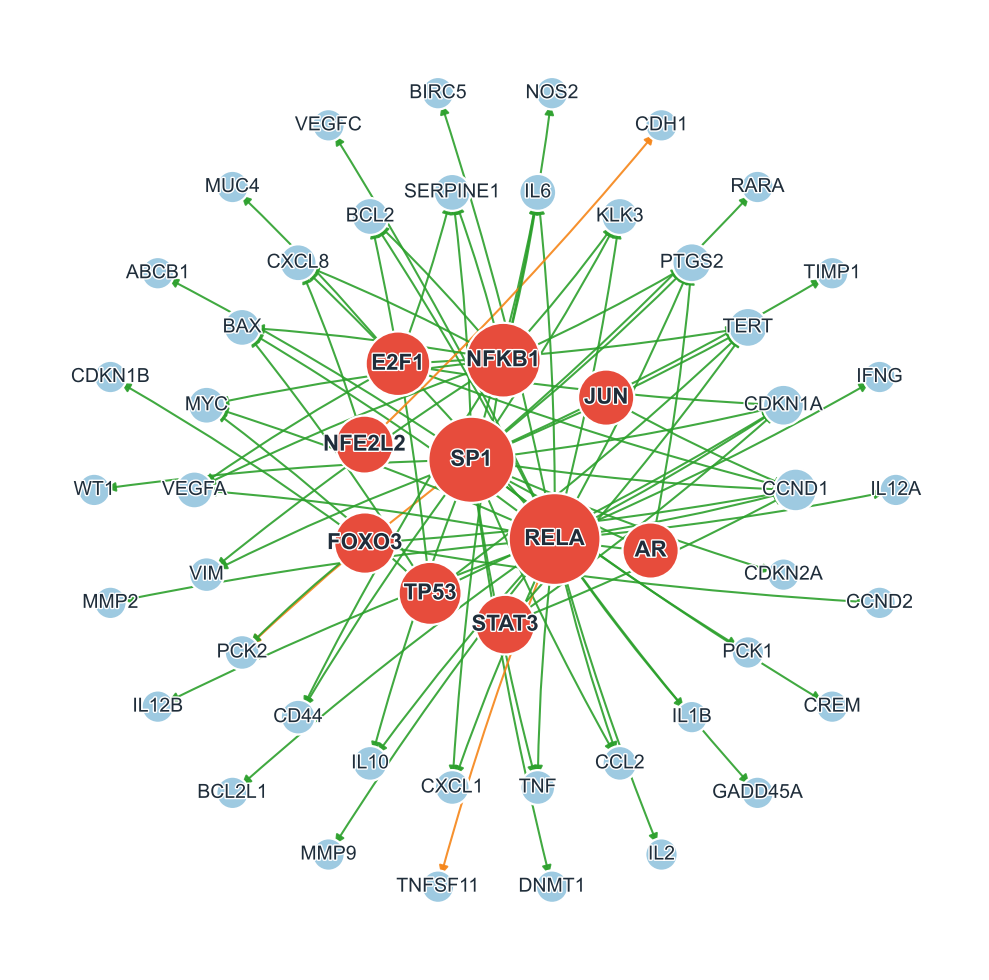

In [15]:
from pathlib import Path
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize, LinearSegmentedColormap
import matplotlib.cm as cm
import random
from networkx.algorithms import community
# ========= 可按需修改的参数 =========
top_n = 100  # 改为固定100个边
result_df  = result_df.head(top_n).copy()
# ========= 构图（有向：TF -> Target） =========
G = nx.DiGraph()
for _, r in result_df.iterrows():
    if float(r["score"]) >= 0:  # 只添加预测激活的边
        G.add_edge(
            r["tf"], r["gene"],
            score=float(r["score"]),
            label=int(r["label"]) if "label" in r and not pd.isna(r["label"]) else None
        )

if G.number_of_nodes() == 0:
    raise RuntimeError("图为空：请检查输入文件/列名或 TOP_FRAC。")

tf_src = {n for n, d in G.out_degree() if d > 0}  # 本图真正作为 TF 的节点

# --- 使用径向布局：TF 在中心、靶基因在外圈 ---
def radial_tf_target_layout(G, tf_nodes, center=(0.5, 0.5), r_outer=0.48, r_inner=0.18, r_inner_gene=0.35, r_outer_gene=0.48, seed=42):
    """
    将 TF 摆在中心小圆，靶基因分为内外两圈均匀摆放。
    - TF：仅用 TF 子图做 spring_layout，再缩放到半径 r_inner 内（大 TF 更靠近中心）
    - 靶基因：按度数降序排序，前一半在内圈 r_inner_gene，后一半在外圈 r_outer_gene
    返回: pos dict(node -> (x, y))，坐标在 [0,1]^2
    """
    cx, cy = center
    tf_nodes = list(tf_nodes)
    tgt_nodes = [n for n in G.nodes() if n not in tf_nodes]

    # 计算度数
    out_deg = dict(G.out_degree())
    in_deg = dict(G.in_degree())
    deg_total = {n: out_deg.get(n, 0) + in_deg.get(n, 0) for n in G.nodes()}

    # 外圈：靶基因按等角度放置
    pos = {}
    if len(tgt_nodes) > 0:
        # 按度数降序排序
        tgt_sorted = sorted(tgt_nodes, key=lambda n: deg_total.get(n, 0), reverse=True)
        mid = len(tgt_sorted) // 2
        inner_targets = tgt_sorted[:mid]
        outer_targets = tgt_sorted[mid:]

        # 内圈靶基因
        if inner_targets:
            thetas = np.linspace(0, 2*np.pi, len(inner_targets), endpoint=False)
            for n, th in zip(inner_targets, thetas):
                pos[n] = (cx + r_inner_gene*np.cos(th), cy + r_inner_gene*np.sin(th))

        # 外圈靶基因
        if outer_targets:
            thetas = np.linspace(0, 2*np.pi, len(outer_targets), endpoint=False)
            for n, th in zip(outer_targets, thetas):
                pos[n] = (cx + r_outer_gene*np.cos(th), cy + r_outer_gene*np.sin(th))

    # 内圈：TF 用 spring_layout，然后缩放到 r_inner 内
    if len(tf_nodes) == 1:
        pos[tf_nodes[0]] = (cx, cy)
    elif len(tf_nodes) > 1:
        tf_sub = G.subgraph(tf_nodes).copy()
        p = nx.spring_layout(tf_sub, seed=seed, k=0.35/np.sqrt(len(tf_nodes)))
        # 归一化到 [-1,1] 再缩放到半径 r_inner
        xs = np.array([p[n][0] for n in tf_nodes]); ys = np.array([p[n][1] for n in tf_nodes])
        xs = (xs - xs.mean()); ys = (ys - ys.mean())
        denom = max(np.max(np.abs(xs)), np.max(np.abs(ys)), 1e-8)
        xs, ys = xs/denom, ys/denom
        # 大 TF 更靠近中心：半径再乘 (1 - norm_outdeg*0.5)
        od = np.array([out_deg.get(n, 0) for n in tf_nodes], dtype=float)
        if od.max() > 0: od = od / od.max()
        radius_scale = 1 - 0.5*od
        for i, n in enumerate(tf_nodes):
            pos[n] = (cx + r_inner*radius_scale[i]*xs[i], cy + r_inner*radius_scale[i]*ys[i])

    return pos

pos = radial_tf_target_layout(
    G, tf_nodes=tf_src,
    center=(0.5, 0.5), r_outer=0.48, r_inner=0.20, r_inner_gene=0.36, r_outer_gene=0.48, seed=42
)

# --- 节点大小（按度），TF 更大，靶基因较小 ---
out_deg = dict(G.out_degree()); in_deg = dict(G.in_degree())
deg_total = {n: out_deg.get(n,0) + in_deg.get(n,0) for n in G.nodes()}

def _scale(vals, lo, hi):
    if not vals: return {}
    v = np.array(list(vals.values()), float); vmin, vmax = v.min(), v.max()
    den = (vmax - vmin) if vmax > vmin else 1.0
    return {k: lo + (vals[k] - vmin) / den * (hi - lo) for k in vals}

size_tf   = _scale({n: out_deg.get(n,0) for n in tf_src}, lo=900, hi=2400)   # 中心大红点
size_gene = _scale({n: deg_total[n] for n in G.nodes() if n not in tf_src}, lo=300, hi=520)
node_size = {**size_gene, **size_tf}

# ===== 统一放大（建议：直径 ×1.35；面积会自动 ×1.35^2）=====
DIAM_SCALE  = 1.35
AREA_SCALE  = DIAM_SCALE ** 2   # node_size 是面积单位

# 放大节点
size_tf   = {k: v * AREA_SCALE for k, v in size_tf.items()}
size_gene = {k: v * AREA_SCALE for k, v in size_gene.items()}
node_size = {**size_gene, **size_tf}

# 按同一比例放大线宽、箭头、字体
LW_EDGE    = 1.1  * DIAM_SCALE     # 边线宽
ARROWSIZE  = 10   * DIAM_SCALE     # 箭头大小
FS_GENE    = int(11 * DIAM_SCALE)  # 靶基因标签字号
FS_TF      = int(12 * DIAM_SCALE)  # TF 标签字号

# --- 颜色：TF 红色，靶基因浅蓝；边：激活=绿、抑制=橙（有箭头） ---
import matplotlib.pyplot as plt
ARROWS = True

node_color = []
for n in G.nodes():
    if n in tf_src:
        node_color.append("#e74c3c")    # TF 红
    else:
        node_color.append("#9ecae1")    # 靶基因浅蓝

edge_colors = []
for u, v, d in G.edges(data=True):
    lbl = d.get("label", 1)             # 真实标签
    if lbl > 0:
        edge_colors.append("#2ca02c")  # 绿：true positive
    else:
        edge_colors.append("#f58518")  # 橙：false positive

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_aspect('equal')  # 保证半径换算准确

# 防重叠：基于节点半径推开TF
import numpy as np
from math import hypot

def sizept2_to_data_radius(size_pt2, ax):
    """
    把节点面积(pt^2)换成“数据坐标”下的半径(0~1)。
    需要在 fig, ax 建好之后调用；假设坐标是[0,1]且ax为等比例。
    """
    r_pt = np.sqrt(size_pt2 / np.pi)            # 点单位的半径
    r_in = r_pt / 72.0                           # 英寸
    bbox  = ax.get_window_extent().transformed(ax.figure.dpi_scale_trans.inverted())
    data_per_in = 1.0 / bbox.width               # 1 英寸对应的数据坐标长度（x 方向）
    return r_in * data_per_in

def repel_with_radii(pos, nodes, radii_map, center=(0.5,0.5), radius=0.20,
                     margin=0.006, iters=400, step=0.9):
    """按 r_i + r_j + margin 推开 TF，并保持在小圆内。"""
    cx, cy = center
    nodes = list(nodes)
    for _ in range(iters):
        moved = False
        for i, a in enumerate(nodes):
            xa, ya = pos[a]
            ra = radii_map[a]
            for b in nodes[i+1:]:
                xb, yb = pos[b]
                rb = radii_map[b]
                dx, dy = xb - xa, yb - ya
                d = hypot(dx, dy)
                target = ra + rb + margin
                if d < 1e-8:
                    dx, dy = np.random.randn(), np.random.randn()
                    d = hypot(dx, dy)
                if d < target:
                    # 往两侧各推一半
                    push = 0.5 * (target - d) * step
                    ux, uy = dx / d, dy / d
                    xa, ya = xa - ux * push, ya - uy * push
                    xb, yb = xb + ux * push, yb + uy * push
                    # 限制回小圆
                    for n, (x, y) in ((a,(xa,ya)), (b,(xb,yb))):
                        dx0, dy0 = x - cx, y - cy
                        r = hypot(dx0, dy0)
                        if r > radius and r > 1e-9:
                            x, y = cx + dx0/r * radius, cy + dy0/r * radius
                        pos[n] = (x, y)
                    moved = True
                else:
                    # 更新a坐标（可能在上一次循环里被改变）
                    xa, ya = pos[a]
        if not moved:
            break

tf_radii_data = {n: sizept2_to_data_radius(node_size[n], ax) for n in tf_src}
repel_with_radii(pos, tf_src, tf_radii_data,
                 center=(0.5,0.5), radius=0.20,
                 margin=0.008, iters=400, step=0.9)

# 边（更粗一点 + 箭头更大 + 轻微弯曲 + 圆头，缩小时不糊）
edges = nx.draw_networkx_edges(
    G, pos, ax=ax,
    edge_color=edge_colors,
    width=LW_EDGE, alpha=0.9,
    arrows=True, arrowstyle='-|>', arrowsize=ARROWSIZE,
    connectionstyle="arc3,rad=0.03",
)
for coll in edges:
    coll.set_capstyle("round")

# 节点（白描边提升对比）
nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_color=node_color,
    node_size=[node_size[n] for n in G.nodes()],
    linewidths=1.2 * DIAM_SCALE, edgecolors="white"
)

# 标签（跟着放大；加白边更清晰）
import matplotlib.patheffects as pe
texts_gene = nx.draw_networkx_labels(G, pos,
    labels={n:n for n in G if n not in tf_src},
    font_size=FS_GENE, font_color="#1f2d3a", font_family='Arial')
texts_tf   = nx.draw_networkx_labels(G, pos,
    labels={n:n for n in tf_src},
    font_size=FS_TF, font_weight="bold", font_color="#1f2d3a", font_family='Arial')
for t in list(texts_gene.values()) + list(texts_tf.values()):
    t.set_path_effects([pe.withStroke(linewidth=2.0, foreground="white")])

ax.set_axis_off()
plt.tight_layout()

### 基因调控图(fig8)

In [16]:
import gseapy as gp
ORGANISM = "Human" 
GENE_SETS = ["KEGG_2021_Human", "GO_Biological_Process_2021"]  
TOPN = 6             # 每张图展示前 N 个 term
# ===== 2) 读取基因列表（单列、可带/不带表头）=====
genes = result_df["gene"].astype(str).str.strip()
genes = genes[genes.ne("")].drop_duplicates().tolist()
print(f"[Info] n_genes={len(genes)}")

# ===== 3) Enrichr/ORA =====
enr = gp.enrichr(gene_list=genes, gene_sets=GENE_SETS,
                 organism=ORGANISM, cutoff=1.0)   # 不先阈值，后面自己筛
res = enr.results.copy()

[Info] n_genes=45


In [17]:
# -*- coding: utf-8 -*-
import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======= 配置 =======
res = r"F:\Program Files\gakkibot\3.GCKMGRN\3.GCKMGRN\Result\Specific\lung 500\enrich_out\enrichr_all_results.csv"
TOPN     = 20  # 导出与可视化的Top基因数

# ======= 1) 读取并清洗 =======
df = pd.read_csv(res)

# 统一列名（不同库导出的标题可能大小写/空格不同）
cols = {c.lower(): c for c in df.columns}
def pick(*names):
    for n in names:
        if n.lower() in cols: return cols[n.lower()]
    return None

col_term  = pick("Term")
col_genes = pick("Genes")
col_padj  = pick("Adjusted P-value", "Adjusted P value", "FDR q-value", "P-value")  # 有就用，没有就退化
if col_term is None or col_genes is None or col_padj is None:
    raise ValueError("缺少必须列：Term / Genes / (Adjusted P-value|FDR q-value|P-value)")

df = df[[col_term, col_genes, col_padj]].rename(columns={col_term:"Term", col_genes:"Genes", col_padj:"Padj"})

# 修复 p=0 下溢：用最小非零p的 1/10 作为地板
p = pd.to_numeric(df["Padj"], errors="coerce")
p_nonzero = p[p>0]
floor = (p_nonzero.min()/10.0) if len(p_nonzero) else 1e-8
p_fixed = p.replace(0, floor).clip(lower=floor, upper=1.0)
df["Padj_fixed"] = p_fixed
df["neglog10"]   = -np.log10(df["Padj_fixed"])

# 拆分条目中的基因集合
def split_genes(x):
    if pd.isna(x): return []
    s = str(x).replace(";", ",")
    return [g.strip() for g in s.split(",") if g.strip()]

df["GeneList"]   = df["Genes"].map(split_genes)
df["Term_size"]  = df["GeneList"].map(len)

# ======= 2) 计算三种关键基因分数 =======
records = []
for _, row in df.iterrows():
    w  = float(row["neglog10"])
    ts = max(int(row["Term_size"]), 1)
    for g in row["GeneList"]:
        records.append((g, w, ts))
tab = pd.DataFrame(records, columns=["Gene", "w", "term_size"])

# A: 频次×显著性
scoreA = tab.groupby("Gene")["w"].sum().rename("ScoreA")

# B: 惩罚大条目
scoreB = tab.assign(wb=tab["w"]/tab["term_size"]).groupby("Gene")["wb"].sum().rename("ScoreB")

# C: TF-IDF风格（df_gene: 出现于多少不同条目）
gene_df = tab.groupby("Gene")["term_size"].count()
N_terms = int(df.shape[0])
idf = (np.log((N_terms + 1) / (gene_df + 1)) + 1.0)  # 平滑
tabC = tab.merge(idf.rename("idf"), left_on="Gene", right_index=True)
scoreC = (tabC["w"]*tabC["idf"]).groupby(tabC["Gene"]).sum().rename("ScoreC")

scores = pd.concat([scoreA, scoreB, scoreC], axis=1).fillna(0.0)

# 标准化并合成最终分数
def z(x):
    mu, sd = x.mean(), x.std(ddof=0)
    return (x - mu) / (sd if sd>0 else 1.0)
scores_z = scores.apply(z)
scores_z["FinalScore"] = scores_z.mean(axis=1)

# 排序导出
ranked = scores.join(scores_z.add_suffix("_z")).sort_values("FinalScore_z", ascending=False)

# ======= 4) 证据链：条目 → 基因 的桑基图（可选） =======
try:
    import plotly.graph_objects as go
    # ===== 固定右侧关键基因（按指定顺序） =====
    FIXED_GENES = ['JUN', 'MYC', 'STAT3', 'STAT1', 'HIF1A', 'NFKB1', 'TP53', 'SP1', 'RELA']
    
    # 每个条目给每个基因的“贡献” = w 或 w/term_size
    df["Contribution"] = df["neglog10"]  # 也可改为 df["neglog10"]/df["Term_size"]
    edges = []
    for _, row in df.sort_values("neglog10", ascending=False).head(1000).iterrows():
        term = row["Term"]; w = float(row["Contribution"]); ts = int(row["Term_size"])
        for g in row["GeneList"]:
            edges.append((term, g, w, ts))
    df_contrib = pd.DataFrame(edges, columns=["Term","Gene","w","term_size"])
    
    # 若基因名大小写不一，先统一到大写：
    df_contrib['Gene'] = df_contrib['Gene'].astype(str).str.upper()
    fixed_set = [g for g in FIXED_GENES if g in set(df_contrib['Gene'])]
    
    if len(fixed_set) == 0:
        raise ValueError("固定基因列表在贡献表中一个都没命中，请检查基因名是否一致/是否需要去掉别名。")
    
    # 仅保留与固定右侧基因有关的贡献边
    df_contrib_fixed = df_contrib[df_contrib['Gene'].isin(fixed_set)].copy()
    
    # ===== 用“固定右侧基因”来重算术语打分并挑选 Top-M 术语 =====
    # 术语得分 = 对这些固定基因的权重累积
    df_term_score = (df_contrib_fixed.groupby('Term')['w']
                     .sum()
                     .sort_values(ascending=False)
                     .reset_index(name='term_score'))
    
    M = 10  # Top-M 术语数
    top_terms = df_term_score['Term'].head(M).tolist()
    
    # 画图用的数据：只保留{top_terms × fixed_set}的连边
    df_plot = df_contrib_fixed[df_contrib_fixed['Term'].isin(top_terms)].copy()
    
    # 右侧基因保持给定顺序
    right_genes = fixed_set  # 顺序即 FIXED_GENES 中的相对顺序
    
    nodes = list(top_terms) + right_genes
    idx   = {n:i for i,n in enumerate(nodes)}
    link_source = df_plot["Term"].map(idx).tolist()
    link_target = df_plot["Gene"].map(idx).tolist()
    link_value  = df_plot["w"].tolist()
    
    # 计算强度
    outgoing_flow = df_plot.groupby("Term")["w"].sum()  # GO outgoing
    incoming_flow = df_plot.groupby("Gene")["w"].sum()  # Gene incoming
    
    # 归一化：log1p scaled
    def log1p_norm(s):
        log_s = np.log1p(s)
        return (log_s - log_s.min()) / (log_s.max() - log_s.min()) if log_s.max() > log_s.min() else [0.5] * len(log_s)
    
    norm_out = log1p_norm(outgoing_flow.reindex(top_terms))
    norm_in = log1p_norm(incoming_flow.reindex(right_genes))
    
    # 生成颜色：左侧Blues，右侧Oranges
    go_colors = [plt.cm.Blues(n) for n in norm_out]
    go_hex = ['#%02x%02x%02x' % (int(r*255), int(g*255), int(b*255)) for r,g,b,a in go_colors]
    gene_colors = [plt.cm.Oranges(n) for n in norm_in]
    gene_hex = ['#%02x%02x%02x' % (int(r*255), int(g*255), int(b*255)) for r,g,b,a in gene_colors]
    node_colors = go_hex + gene_hex
    
    # 连线：灰色，透明度0.65
    link_colors = ['rgba(128,128,128,0.65)'] * len(link_value)
    
    fig = go.Figure(go.Sankey(
        arrangement="snap",
        node=dict(label=nodes, pad=20, thickness=14, line=dict(color='black', width=2), color=node_colors),
        link=dict(source=link_source, target=link_target, value=link_value, color=link_colors),
        domain=dict(x=[0.12, 0.88])  # 压缩主图，留空间给色条
    ))
    fig.update_layout(width=3000, height=950,
                      margin=dict(l=150, r=150, t=50, b=50),  # 增加边距避免遮挡
                      font=dict(family="Arial Black, Arial", size=26, color='black'),
                      template=None,
                      paper_bgcolor='rgba(0,0,0,0)',
                      plot_bgcolor='rgba(0,0,0,0)')
    
    # 添加左侧色条：GO flow (Blues)
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(
            size=0,
            color=[0, 1],  # 0-1归一化
            colorscale='Blues',
            showscale=True,
            colorbar=dict(
                title=dict(side='right'),
                x=0.04, xanchor='left', y=0.5, yanchor='middle',
                len=0.82, thickness=16,
                bgcolor='rgba(255,255,255,0.0)', borderwidth=0
            )
        ),
        showlegend=False
    ))
    
    # 添加右侧色条：Gene flow (Oranges)，标题用annotation
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(
            size=0,
            color=[0, 1],  # 0-1归一化
            colorscale='Oranges',
            showscale=True,
            colorbar=dict(
                title=dict(side='right'),  # 标题置空，用annotation
                x=0.96, xanchor='right', y=0.5, yanchor='middle',
                len=0.82, thickness=16,
                bgcolor='rgba(255,255,255,0.0)', borderwidth=0
            )
        ),
        showlegend=False
    ))
    
    # 添加右侧色条标题annotation
    fig.add_annotation(
        x=1.00, y=0.5, xref='paper', yref='paper',
        showarrow=False, textangle=-90,
        font=dict(size=26, color='black')
    )
    
    # 隐藏笛卡尔坐标轴
    fig.update_xaxes(visible=False)
    fig.update_yaxes(visible=False)

    # ② 先显示，再保存（或反过来也行）
    fig.show()

except Exception as e:
    # ③ 不要静默吞错，至少打个日志
    print("[Plotly Sankey ERROR]", repr(e))